In [18]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib
import torch
import logging 
from pathlib import Path
import random
import numpy as np

import method.datasets as ds
import method.preprocess.preprocess as ps
import method.core.pipeline as pipe
import method.models.rnn.rnn as model

from method.metrics import metrics
from logging_tools.config import setup_logging
from method.viz import plot_data, plot_results, plot_data_compare

import data_configs.base_interp_data as config

CONFIGS_PATH = Path("configs")
DATASET_CONFIG = ds.DatasetConfig.from_dict(config.EXECUTE_CONFIG["dataset"])

setup_logging()
logger = logging.getLogger(__name__)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO     Preprocessor.transform start

INFO     Pipeline making step 'shifter'

INFO     Pipeline making step 'drop_intervals'

INFO     Pipeline making step 'filter'

INFO     Pipeline making step 'interpolation'

INFO     Pipeline making step 'scaler'

INFO     Pipeline making step 'feature_selector'

INFO     Pipeline making step 'splitter'

INFO     Preprocessor.transform end (0.27)s

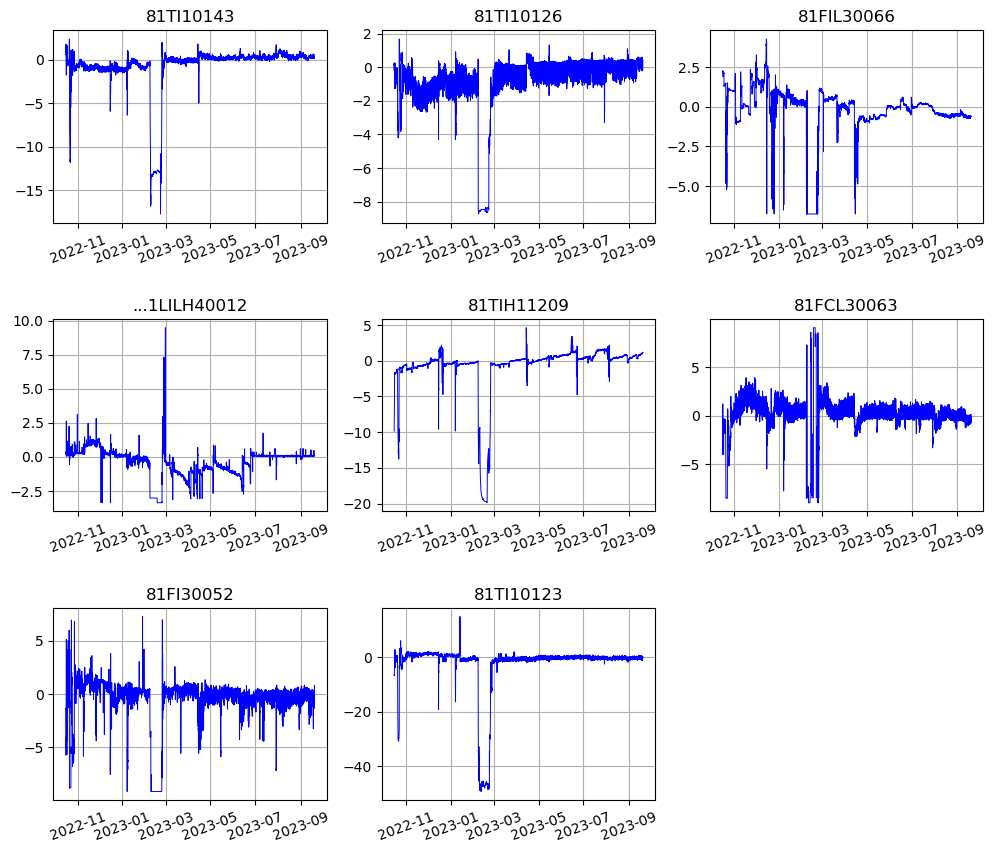

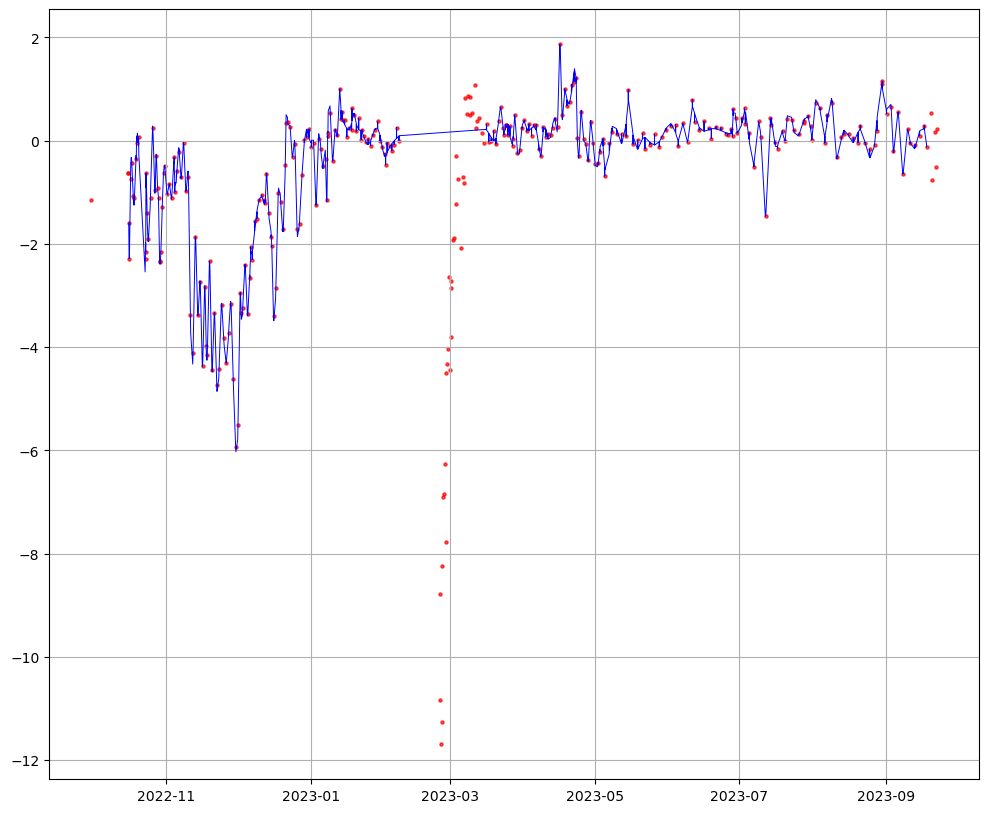

In [19]:
data_raw = ds.LoadDatasetStep(DATASET_CONFIG).fit_transform()

preprocess_config = ps.PreprocessConfig.from_dict(config.EXECUTE_CONFIG["preprocess"])
preprocessor = ps.Preprocessor(preprocess_config)

data = preprocessor.fit_transform(data_raw)

data_merged = data.merge_data()
ds_raw = data_raw.train.replace(new_y_scaler=data.train.y_scaler)
target_raw_scaled = ds_raw.scale(scale_y=True).y
target = data_merged.train.y
plot_data(data_merged.train.X.dropna(), plot_type="plot")
plot_data_compare(target_raw_scaled.dropna(), target.dropna())

INFO     RNN training model

INFO     Computing best lag using spearman correlation...

INFO     epoch 0: train: 1.8615, lr: 1.000e-02, valid: 0.1828, best_valid: 0.1828

INFO     epoch 10: train: 0.1889, lr: 1.000e-02, valid: 0.3485, best_valid: 0.1732

INFO     epoch 20: train: 0.1748, lr: 1.000e-02, valid: 0.5523, best_valid: 0.1732

INFO     epoch 30: train: 0.1854, lr: 1.000e-02, valid: 0.1878, best_valid: 0.1732

INFO     epoch 40: train: 0.1099, lr: 1.000e-02, valid: 0.3151, best_valid: 0.1732

INFO     epoch 50: train: 0.1276, lr: 1.000e-02, valid: 0.4470, best_valid: 0.1732

INFO     RNN Model trained

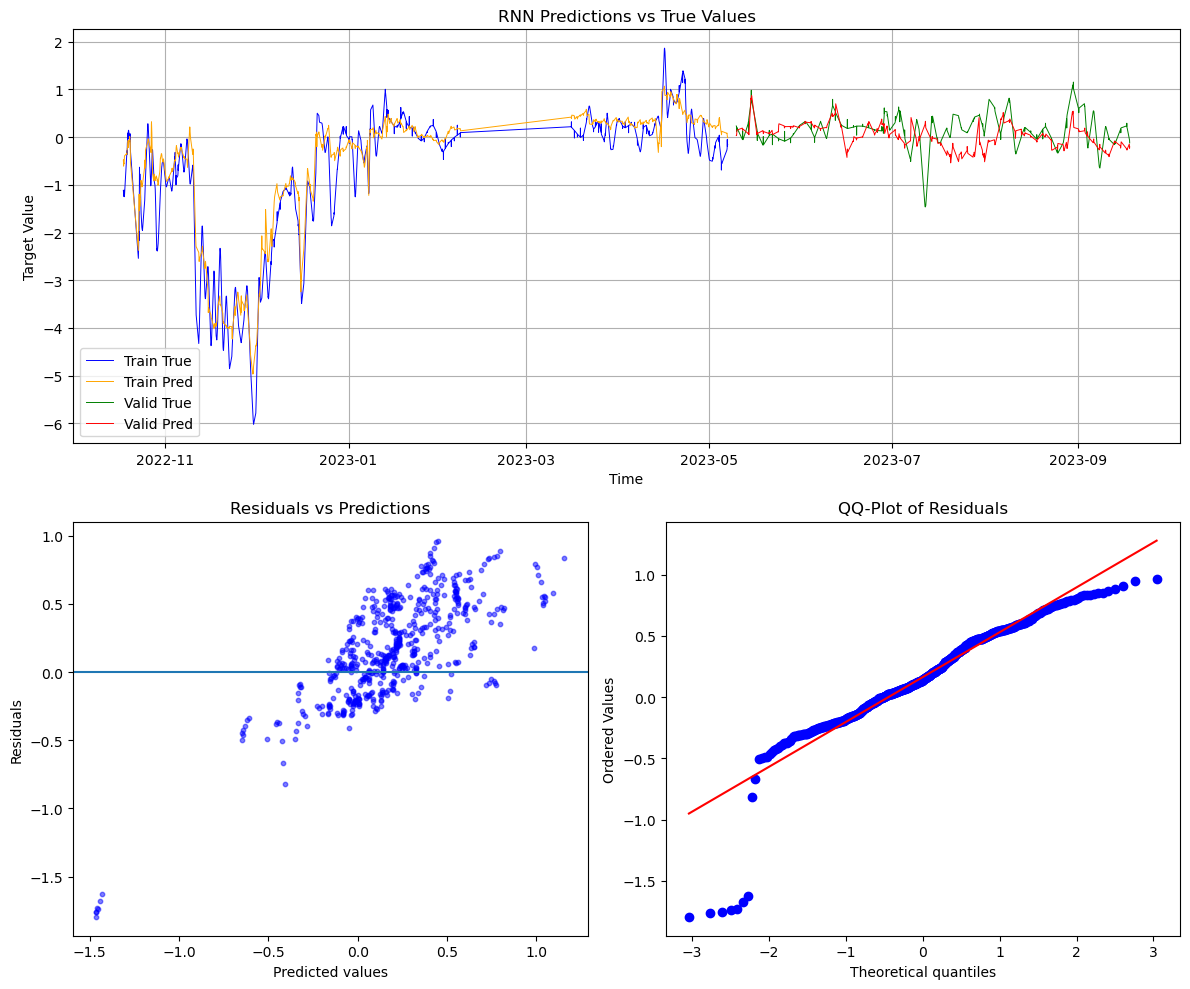

INFO     Metrics for Valid:

INFO                                                                                                               
         MAE                   0.315650                                                                            
         rMSE                  0.416168                                                                            
         MAPE                 11.750589                                                                            
         Pearson (p-value)     0.000001                                                                            
         Pearson               0.197455                                                                            
         R2                   -0.483963                                                                            
         Hinge                 0.227516                                                                            
         dtype: float64

In [20]:
torch.manual_seed(0)
np.random.seed(42)
random.seed(42)

rnn_config = model.RNNConfig.from_dict(config.EXECUTE_CONFIG["model"])
rnn = model.RNN(rnn_config)

steps = [("rnn", rnn)]
full_pipeline = pipe.Pipeline(steps)  # type: ignore
result = full_pipeline.fit_transform(data)

plot_results(result)

logger.debug("Metrics for Train:")
logger.debug("\n%s", metrics(**result["train"], cone=0.1))
logger.info("Metrics for Valid:")
logger.info("\n%s", metrics(**result["valid"], cone=0.1))